In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("datasets/features_dataset.csv")

In [3]:
df.shape

(336749, 54)

In [4]:
df_corr = df.drop(columns=["URL","File_Extension","Suffix"])

In [5]:
df_corr["Label"] = df_corr["Label"].map({
    "Phishing":1,
    "Legitimate":0
})


In [6]:
corr_matrix = df_corr.corr()

Matplotlib is building the font cache; this may take a moment.


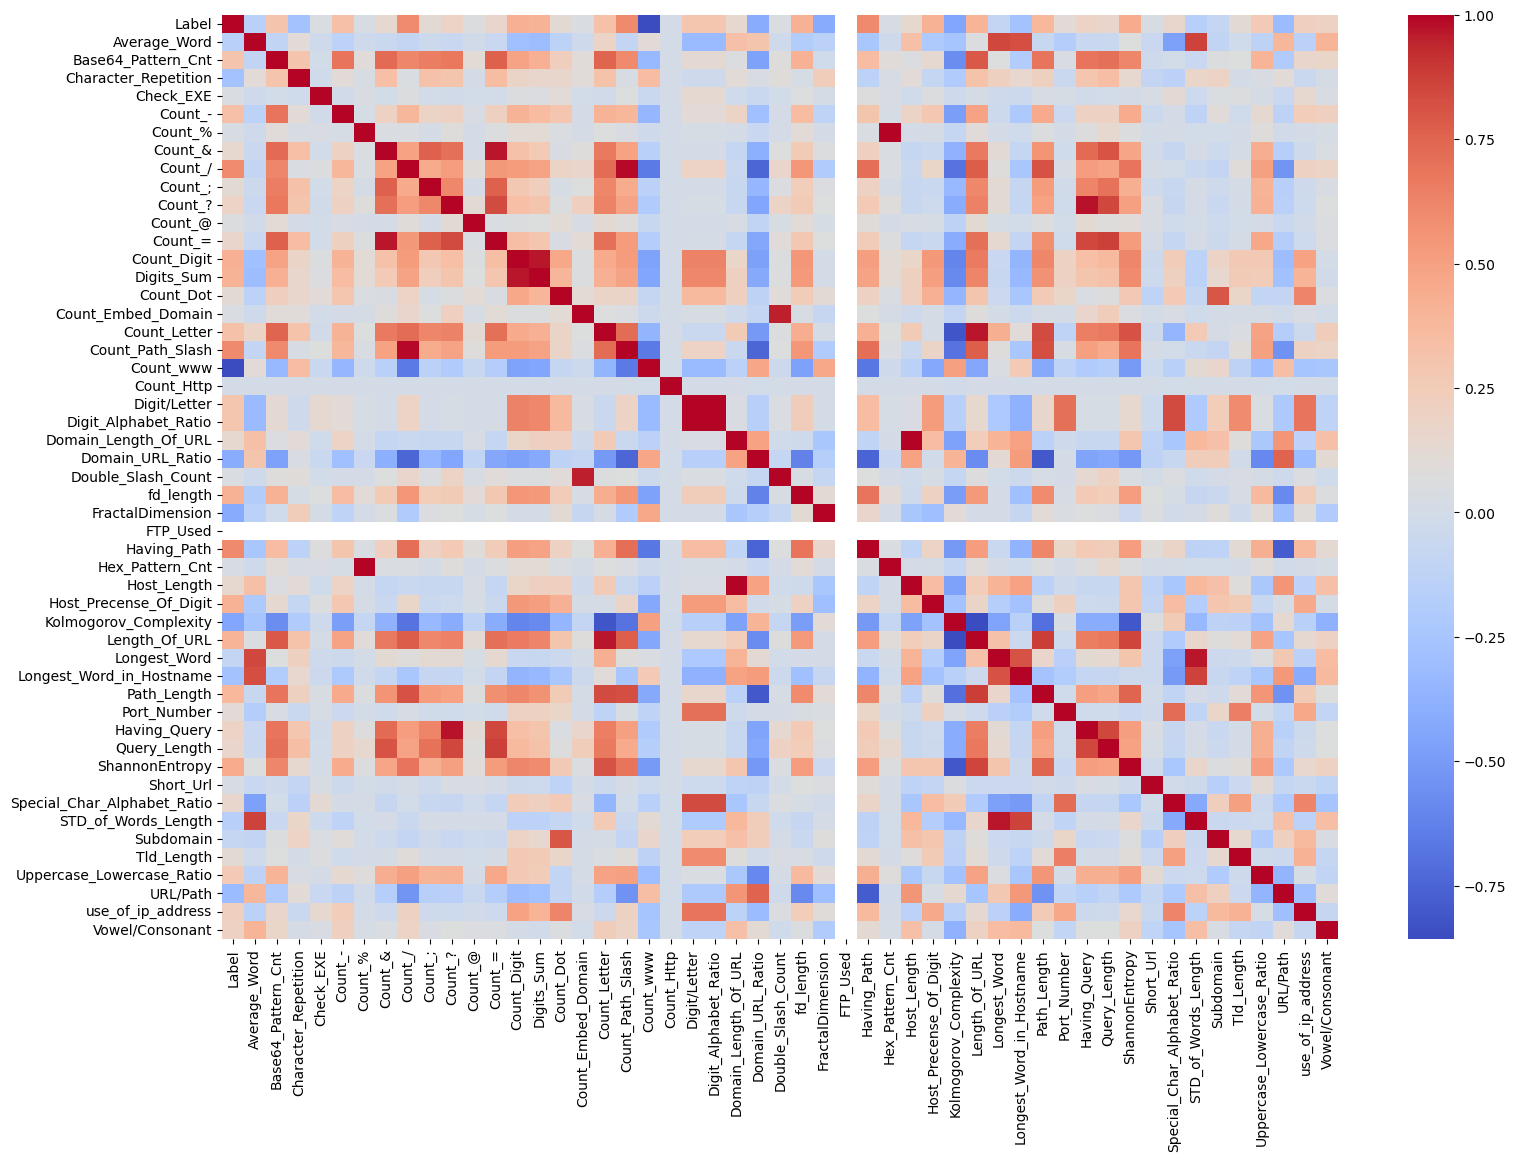

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(18,12))
sns.heatmap(corr_matrix, cmap="coolwarm")
plt.show()

In [8]:
corr_matrix

,Label,Average_Word,Base64_Pattern_Cnt,Character_Repetition,Check_EXE,Count_-,Count_%,Count_&,Count_/,Count_;,...,ShannonEntropy,Short_Url,Special_Char_Alphabet_Ratio,STD_of_Words_Length,Subdomain,Tld_Length,Uppercase_Lowercase_Ratio,URL/Path,use_of_ip_address,Vowel/Consonant
Label,1.000000,-0.158944,0.306546,-0.274269,0.045445,0.329082,0.029694,0.140918,0.599700,0.121874,...,0.443265,0.033377,0.158212,-0.166074,-0.082451,0.122011,0.264537,-0.318123,0.222449,0.197252
Average_Word,-0.158944,1.000000,-0.109471,0.103632,-0.027955,-0.132201,-0.027021,-0.055699,-0.092351,-0.042159,...,0.065004,-0.061129,-0.476367,0.868279,-0.106550,-0.015933,-0.130460,0.387902,-0.144899,0.400786
Base64_Pattern_Cnt,0.306546,-0.109471,1.000000,0.307338,-0.002049,0.692547,0.100103,0.730705,0.616582,0.657823,...,0.621910,-0.029959,-0.002091,-0.066261,0.057658,0.066542,0.402054,-0.201931,0.161644,0.166972
Character_Repetition,-0.274269,0.103632,0.307338,1.000000,-0.017338,0.103086,0.033301,0.338718,0.043766,0.322426,...,0.137669,-0.089880,-0.143052,0.172881,0.192151,0.004521,0.040207,0.105019,-0.053357,0.019665
Check_EXE,0.045445,-0.027955,-0.002049,-0.017338,1.000000,-0.012969,0.040135,-0.006996,0.063671,-0.006050,...,0.004876,0.030612,0.124319,-0.031975,0.044919,0.061018,0.020620,-0.066240,0.138387,0.041839
Count_-,0.329082,-0.132201,0.692547,0.103086,-0.012969,1.000000,0.024375,0.198501,0.386075,0.182705,...,0.444728,-0.044145,0.009881,-0.120849,0.099306,-0.016202,0.131659,-0.130241,0.244809,0.222928
Count_%,0.029694,-0.027021,0.100103,0.033301,0.040135,0.024375,1.000000,0.046538,0.049591,0.019616,...,0.057997,0.002502,0.013642,-0.006284,-0.007028,0.008430,0.081979,-0.010140,0.001877,0.023862
Count_&,0.140918,-0.055699,0.730705,0.338718,-0.006996,0.198501,0.046538,1.000000,0.497103,0.762589,...,0.481157,-0.009551,-0.076598,0.010859,-0.030072,0.017218,0.440371,-0.173070,-0.027361,0.042733
Count_/,0.599700,-0.092351,0.616582,0.043766,0.063671,0.386075,0.049591,0.497103,1.000000,0.451080,...,0.694912,0.014186,-0.002349,-0.054392,-0.093532,0.088412,0.502831,-0.534396,0.202783,0.182215
Count_;,0.121874,-0.042159,0.657823,0.322426,-0.006050,0.182705,0.019616,0.762589,0.451080,1.000000,...,0.432659,-0.024215,-0.072837,0.014281,-0.024699,0.016304,0.409311,-0.161566,-0.024139,0.036479


In [9]:
import numpy as np

corr_matrix = df_corr.corr().abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr_features = [column for column in upper.columns if any(upper[column] > 0.90)]

high_corr_features

['Count_=',
 'Digits_Sum',
 'Count_Path_Slash',
 'Digit_Alphabet_Ratio',
 'Double_Slash_Count',
 'Hex_Pattern_Cnt',
 'Host_Length',
 'Length_Of_URL',
 'Having_Query',
 'STD_of_Words_Length']

In [10]:
df_reduced = df_corr.drop(columns=high_corr_features)

In [11]:
df_reduced.shape

(336749, 41)

In [24]:
#  Feature Selection with Mutual Information

In [19]:
X = df_reduced.drop('Label', axis=1)
y = df_reduced['Label']

In [20]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd

# X = feature'lar
# y = label (0-1)

mi_scores = mutual_info_classif(X, y)

mi_df = pd.DataFrame({
    'Feature': X.columns,
    'MI_Score': mi_scores
})

# büyükten küçüğe sırala
mi_df = mi_df.sort_values(by='MI_Score', ascending=False)

print(mi_df)

                        Feature  MI_Score
19             Domain_URL_Ratio  0.557016
15                    Count_www  0.510058
7                       Count_/  0.455658
28                  Path_Length  0.436719
37                     URL/Path  0.308031
2          Character_Repetition  0.275650
23                  Having_Path  0.256970
33  Special_Char_Alphabet_Ratio  0.254676
31               ShannonEntropy  0.240416
20                    fd_length  0.239100
17                 Digit/Letter  0.218948
11                  Count_Digit  0.218617
25        Kolmogorov_Complexity  0.187066
0                  Average_Word  0.174820
21             FractalDimension  0.154019
14                 Count_Letter  0.149956
39              Vowel/Consonant  0.136272
12                    Count_Dot  0.130607
1            Base64_Pattern_Cnt  0.114593
24       Host_Precense_Of_Digit  0.110530
18         Domain_Length_Of_URL  0.106807
34                    Subdomain  0.101169
4                       Count_-  0

In [21]:
selected_features = mi_df[mi_df['MI_Score'] > 0.01]['Feature']
X_selected = X[selected_features]

In [22]:
X_selected.shape

(336749, 34)

In [23]:
X_selected.head()

,Domain_URL_Ratio,Count_www,Count_/,Path_Length,URL/Path,Character_Repetition,Having_Path,Special_Char_Alphabet_Ratio,ShannonEntropy,fd_length,...,Longest_Word_in_Hostname,Count_Embed_Domain,Tld_Length,use_of_ip_address,Longest_Word,Count_?,Query_Length,Count_&,Count_;,Port_Number
0,0.904762,0,2,0,84.000000,3,0,0.116667,4.739567,0,...,10,1,3,0,10,0,0,0,0,0
1,0.500000,0,3,13,3.076923,5,1,0.642857,3.808271,12,...,0,1,8,1,7,0,0,0,0,8090
2,0.678571,0,3,1,28.000000,3,0,0.300000,4.056021,0,...,7,1,3,0,7,0,0,0,0,0
3,0.741935,0,3,1,31.000000,3,0,0.240000,3.827833,0,...,14,1,3,0,14,0,0,0,0,0
4,0.652174,1,2,0,23.000000,4,0,0.352941,3.346439,0,...,4,1,2,0,5,0,0,0,0,0


In [27]:
df_final = pd.concat([X_selected, y], axis=1)

In [ ]:
df_final.to_csv("datasets/dataset_final.csv", index=False)